# Bayesian Model Mixing using Gaussian Processes: Nonstationary Kernel Tutorial

## Author: Alexandra C. Semposki

### Date: 04 March 2026

Welcome to the second tutorial for the Gaussian process (GP) model mixing module in `Taweret`! Here we will go over the case of using a nonstationary kernel for your GP prior on the function space. This will entail designing a custom kernel in `scikit-learn`. We include in `Taweret` the custom kernel we have used to generate the results in [this paper](https://arxiv.org/abs/2505.18921); of course, if you wish, you may design your own custom kernel and add it to the file we have included here. 

Let's first load the toy models we will be using and import necessary packages to this notebook.

In [92]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.linalg import block_diag
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

# load the proper location in Taweret for this case
import sys
sys.path.append('../../../src/Taweret')
from Taweret.models.samba_models import *
from mix.gp_bmm import *
from utils.kernels import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# now we write out the models we need
orders=[3,4]
model_1 = Loworder(order=orders[0])
model_2 = Highorder(order=orders[1])

# make the model dict
models = {
    "1": model_1,
    "2": model_2
}

print(models, type(models))

#predict functions for the plot
g = np.linspace(1e-6, 1.0, 100)
predict = []

for i in models.keys():
    predict.append(models[i].evaluate(g))

{'1': <Taweret.models.samba_models.Loworder object at 0x107e60550>, '2': <Taweret.models.samba_models.Highorder object at 0x10f1df310>} <class 'dict'>


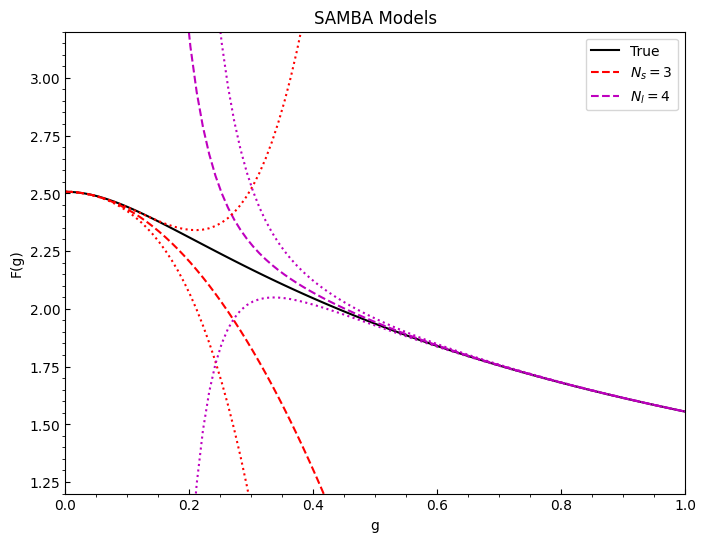

In [3]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

ax.legend()

We first need to build the covariance matrix again since we will need to train a GP that requires knowledge about input-space correlations.

In [101]:
def build_cov_from_errors(x, sigma, ell=10.0, nugget=1e-6):
    x = np.asarray(x)
    sigma = np.asarray(sigma)

    dx = x[:, None] - x[None, :]
    rho = np.exp(-0.5 * (dx / ell)**2)

    C = np.outer(sigma, sigma) * rho
    C += nugget * np.eye(len(x))
    return C

# take some training data from these, and make some covariances up for the toy case
x1 = g[:30:3]
x2 = np.append(g[40:-1:5], g[-1])

# cut the data as well
data1 = predict[0][0][:30:3]
sigma1 = predict[0][1][:30:3]
data2 = np.append(predict[1][0][40:-1:5], predict[1][0][-1])
sigma2 = np.append(predict[1][1][40:-1:5], predict[1][1][-1])

# try the covariance function here
cov1 = build_cov_from_errors(x1, sigma1, ell=0.1, nugget=1e-6)
cov2 = build_cov_from_errors(x2, sigma2, ell=1.0, nugget=1e-6)

# build full alpha covariance matrix for the GPmixing step
xtot = np.concatenate((x1, x2))
datatot = np.concatenate((data1, data2))
alpha = block_diag(cov1, cov2)

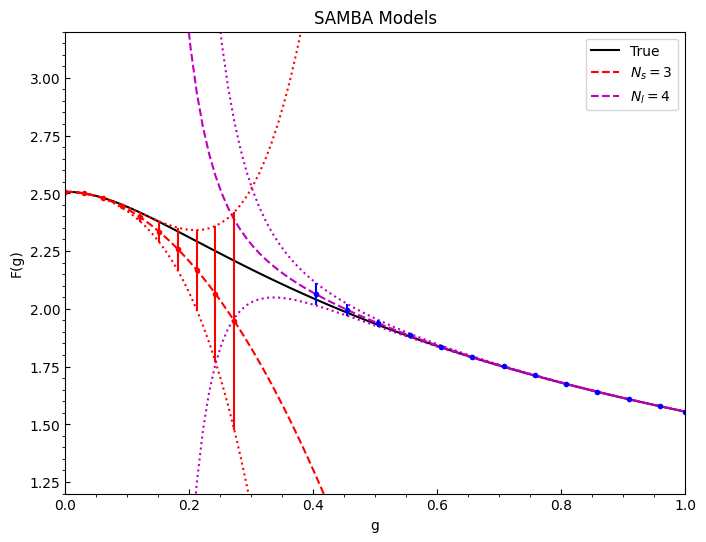

In [46]:
#basic plot to check choices
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

ax.legend()
plt.show()

Now we will design what we will call a nonstationary kernel, which means it will depend on the input space (here, on our location in $g$). To do this, we first will define frozen GP kernels that will emulate our models. We do this here because it allows us to quickly design a kernel that has the necessary positive-definite characteristic the GP relies on. We do this below by defining our frozen kernels and plotting their results on top of our models.

22.4**2 * RBF(length_scale=0.15)


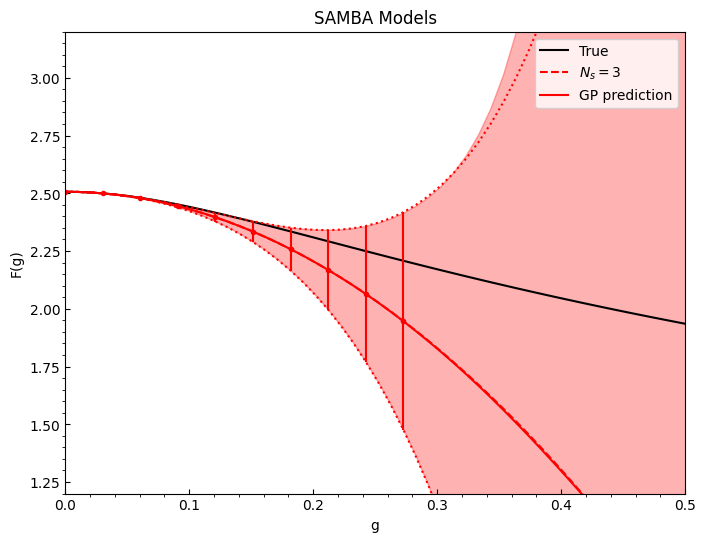

In [89]:
# write the frozen GP kernels
k1_ls = 0.15
k1_c2 = 500.0
k1 = C(constant_value=k1_c2, constant_value_bounds='fixed') * RBF(length_scale=k1_ls, length_scale_bounds='fixed')

gp1 = GPRwrapper(
    kernel=k1,
    alpha = cov1,
)

gp1.fit(x1.reshape(-1,1), data1.reshape(-1,1))

print(gp1.kernel_)

gp1_predict, gp1_std_predict = gp1.predict(g.reshape(-1,1), return_std=True)
_, gp1_cov_predict = gp1.predict(g.reshape(-1,1), return_cov=True)

# plot the result quickly to test
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,0.5)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
ax.plot(g, predict[0][0].flatten(), color=colors[0], linestyle=lines[0], label=labels[0])

#uncertainties
ax.plot(g, predict[0][0].flatten() - predict[0][1].flatten(), color=colors[0], linestyle=lines[1])
ax.plot(g, predict[0][0].flatten() + predict[0][1].flatten(), color=colors[0], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')

# GP prediction
ax.plot(g, gp1_predict, color='red', label='GP prediction')
ax.fill_between(g, gp1_predict-gp1_std_predict, gp1_predict+gp1_std_predict, alpha=0.3, color='red')

ax.legend()
plt.show()

2.24**2 * RBF(length_scale=0.15)


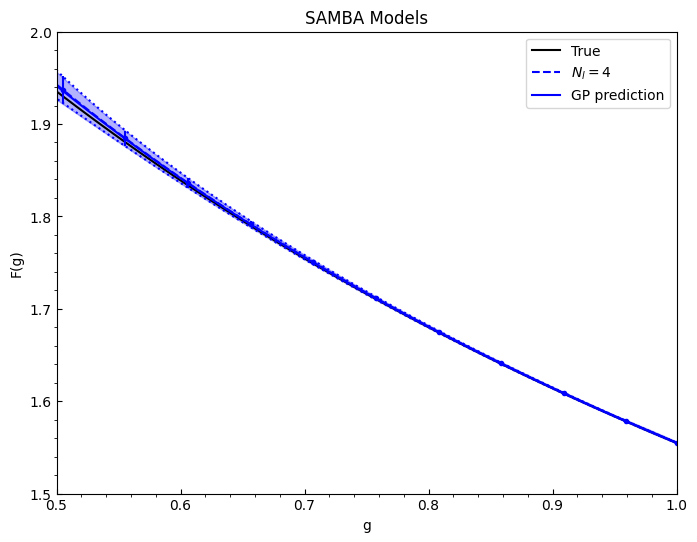

In [88]:
# write the frozen GP kernels
k2_ls = 0.15
k2_c2 = 5.0
k2 = C(constant_value=k2_c2, constant_value_bounds='fixed') * RBF(length_scale=k2_ls, length_scale_bounds='fixed')

gp2 = GPRwrapper(
    kernel=k2,
    alpha = cov2,
)

gp2.fit(x2.reshape(-1,1), data2.reshape(-1,1))

print(gp2.kernel_)

gp2_predict, gp2_std_predict = gp2.predict(g.reshape(-1,1), return_std=True)
_, gp2_cov_predict = gp2.predict(g.reshape(-1,1), return_cov=True)

# plot the result quickly to test
fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.5, 1.0)
ax.set_ylim(1.5, 2.0)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
ax.plot(g, predict[1][0].flatten(), color=colors[2], linestyle=lines[0], label=labels[1])

#uncertainties
ax.plot(g, predict[1][0].flatten() - predict[1][1].flatten(), color=colors[2], linestyle=lines[1])
ax.plot(g, predict[1][0].flatten() + predict[1][1].flatten(), color=colors[2], linestyle=lines[1])

# add data and covariances
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# GP prediction
ax.plot(g, gp2_predict, color='blue', label='GP prediction')
ax.fill_between(g, gp2_predict-gp2_std_predict, gp2_predict+gp2_std_predict, alpha=0.3, color='blue')

ax.legend()
plt.show()

We do not care that this does not match outside of our data region, since we do not trust that region in terms of the original model. Here we are only concerned with matching the behaviour of the data we take from the model, so that we may construct a reasonable changepoint kernel.

In [136]:
# set up the kernel for the changepoint construction
kernelCP = SigmoidChangepoint(ls1=k1_ls, ls2=k2_ls, cbar1=k1_c2, cbar2=k2_c2, changepoint=0.3,
                             changepoint_bounds=[0.2, 0.6], width=0.2, width_bounds=[0.1, 0.3])

# set up prior dict for the different hyperparameters
prior_dict = {
    'w': 'truncnorm',
    'cp': 'truncnorm',
    'switch': 'sigmoid',
}

In [137]:
# set up the model mixing step
gpmix = GPmixing(x=g, models=models, alpha=alpha, kernel=kernelCP, mean_function="zero", priors=True, prior_params=None, 
                 prior_choice='changepoint', prior_type=prior_dict, switch='sigmoid', nopt=5000)

In the above, we have taken `prior_params=None`, which means we will be using the default hyperpriors set in the code for the changepoint kernel case, since we set `prior_choice='changepoint'`. A user can of course enter their own priors for the GP to use!

In [138]:
# fit and predict using the changepoint kernel
gpmix.train(xtot.reshape(-1,1), datatot.reshape(-1,1), prior_choice='changepoint', prior_type=prior_dict, switch='sigmoid')
print(gpmix.gpr.kernel_)

SigmoidChangepoint(changepoint=0.279, width=0.237)


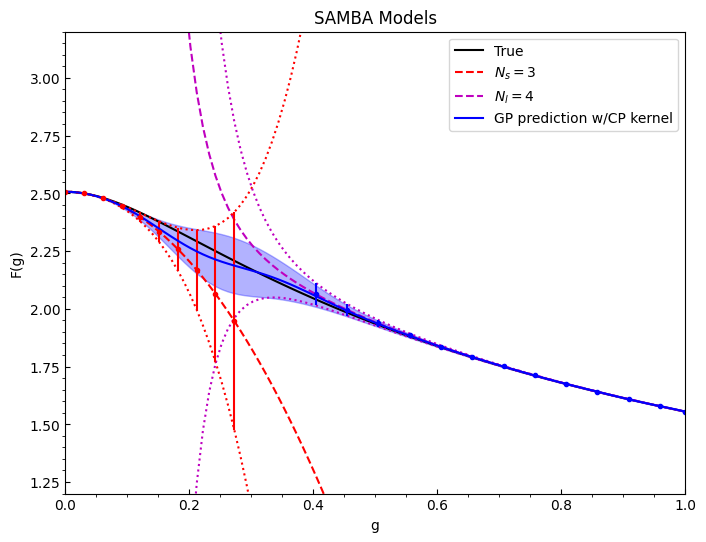

In [141]:
# plot the resulting predictions
gpmix_pred = gpmix.predict()

fig = plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes()
ax.set_xlim(0.0,1.0)
ax.set_ylim(1.2,3.2)
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')
ax.locator_params(nbins=8)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_title('SAMBA Models')
ax.set_xlabel('g')
ax.set_ylabel('F(g)')

#truth
ax.plot(g, TrueModel().evaluate(g)[0].flatten(), 'k', label='True')

#colour wheel
colors = ['r', 'm', 'b']
lines = ['dashed', 'dotted']
labels= [r'$N_s=3$', r'$N_l=4$']

#models
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten(), color=colors[i], linestyle=lines[0], label=labels[i])

#uncertainties
for i in range(len(predict)):
    ax.plot(g, predict[i][0].flatten() - predict[i][1].flatten(), color=colors[i], linestyle=lines[1])
    ax.plot(g, predict[i][0].flatten() + predict[i][1].flatten(), color=colors[i], linestyle=lines[1])

# add data and covariances
ax.errorbar(x1, data1, sigma1, marker='.', color='red', linestyle=' ')
ax.errorbar(x2, data2, sigma2, marker='.', color='blue', linestyle=' ')

# add GP predictions with changepoint kernel
ax.plot(gpmix_pred['x'], gpmix_pred['mean'], color=colors[2], label='GP prediction w/CP kernel')
ax.fill_between(gpmix_pred['x'], gpmix_pred['mean']-gpmix_pred['std'], gpmix_pred['mean']+gpmix_pred['std'], alpha=0.3, color=colors[2])

ax.legend()
plt.show()

This result is very good!